# Random Forest Regressor

## Problem Statement

In this notebook, we will implement the Random Forest Regressor algorithm using Python.

Random Forest Regressor is used to predict continuous numerical values.  
It creates multiple decision trees and combines their results to make better predictions.

## Dataset Used

We will use the **Auto MPG Dataset** from Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns

## Dataset Loading

Now we will load the Auto MPG dataset and convert it into a Pandas DataFrame.

In [2]:
df = sns.load_dataset("mpg")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Exploratory Data Analysis (EDA)

In this step, we will check:

- Dataset shape
- Missing values
- Data types
- Statistical summary
- Correlation analysis
- Visualization

In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (398, 9)

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [4]:
df.select_dtypes(include=["int64", "float64"]).corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


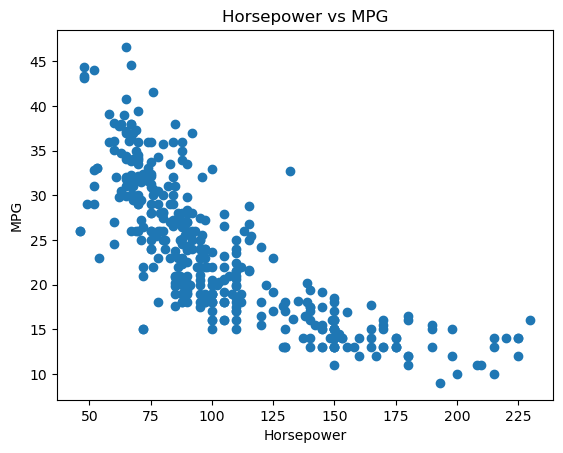

In [5]:
plt.scatter(df["horsepower"], df["mpg"])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

## Data Preprocessing

In this dataset:

- Some missing values may be present
- Categorical columns need encoding
- Target column is MPG

We will handle missing values and encode categorical columns.

In [6]:
df = df.dropna()

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [7]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa,name_amc ambassador dpl,...,name_volvo 145e (sw),name_volvo 244dl,name_volvo 245,name_volvo 264gl,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom
0,18.0,8,307.0,130.0,3504,12.0,70,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa,name_amc ambassador dpl,name_amc ambassador sst,...,name_volvo 145e (sw),name_volvo 244dl,name_volvo 245,name_volvo 264gl,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom
0,8,307.0,130.0,3504,12.0,70,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,8,350.0,165.0,3693,11.5,70,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8,318.0,150.0,3436,11.0,70,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,8,304.0,150.0,3433,12.0,70,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8,302.0,140.0,3449,10.5,70,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


## Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (313, 308)
Testing Data: (79, 308)


## Model Building

Now we will create the Random Forest Regressor model.

n_estimators means the number of decision trees used in the forest.

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

## Model Training

Now we will train the Random Forest Regressor model using training data.

In [12]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Prediction

Now we will predict MPG values using testing data.

In [13]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([26.198, 22.35 , 34.406, 29.952, 27.059, 28.267, 12.77 , 28.25 ,
       19.481, 30.814])

## Model Evaluation

We will evaluate the model using:

- MAE
- MSE
- RMSE
- R² Score

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.7031265822784813
MSE: 5.605218417721518
RMSE: 2.3675342484791044
R2 Score: 0.890181144847429


## Result Interpretation

Random Forest Regressor combines multiple decision trees to improve prediction accuracy.

A lower RMSE means fewer prediction errors.  
A higher R² score means the model explains the target values better.

In [15]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
79,26.0,26.198
276,21.6,22.350
248,36.1,34.406
56,26.0,29.952
393,27.0,27.059
205,28.0,28.267
43,13.0,12.770
235,26.0,28.250
152,19.0,19.481
117,29.0,30.814


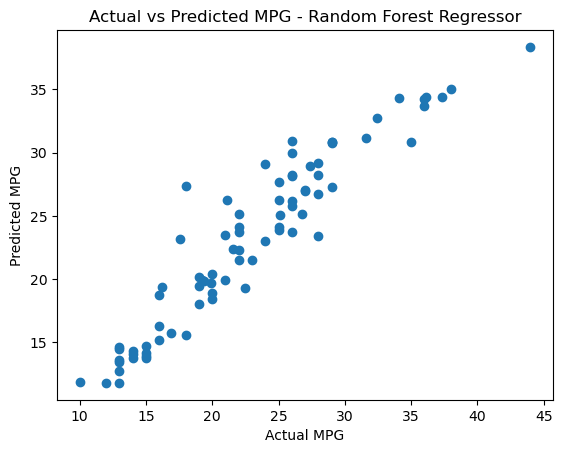

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG - Random Forest Regressor")
plt.show()

importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Feature Importance - Random Forest Regressor")
plt.show()

## Conclusion

In this notebook, we successfully implemented Random Forest Regressor using Python.

We performed:

- Dataset loading
- Exploratory Data Analysis
- Data preprocessing
- Train-test split
- Model building
- Model training
- Model prediction
- Model evaluation
- Result interpretation

Random Forest Regressor is useful for predicting continuous values such as mileage, house prices, sales, or temperature.